# Activity 5: Modelling the Re-introduction of Wolves


-------
## Overview

In this lesson, we go back to the start and **add wolves** to our ecosystem model.

You will think about and explore:

1. How **plants and deer** affect each other
2. Whether the **plant–deer system** is a stable ecosystem
3. What happens to the **wolf population** when wolves are introduced
4. How the **deer population** changes after wolves are added
5. How the **plant population** changes after wolves are added
6. What happens to the **whole ecosystem** (plants and deer together) after wolves are introduced
7. What the simulation predicts when we add **different numbers of wolves**


In [13]:

# Import the NumPy library for numerical operations and array handling
import numpy as np

# Import the math module for mathematical functions like sqrt, sin, etc.
import math 

# Enable inline plotting in Jupyter Notebook so plots appear within the notebook
%matplotlib inline

# Import Matplotlib's pyplot module for creating plots and visualizations
import matplotlib.pyplot as plt  # side-stepping mpl backend

# Import gridspec from Matplotlib for creating complex subplot layouts
import matplotlib.gridspec as gridspec  # subplots

# Import interact and FloatSlider from ipywidgets to create interactive widgets
from ipywidgets import interact, FloatSlider

# Import warnings module to manage warning messages (e.g., ignore or display them)
import warnings


# Predator and Prey 
## Deers and Plants
The cyclical relationship of Predators and Prey in the wild  means that when there is an abundance of prey, the predators will eat more and the prey population will increase. On the other hand, if there is a shortage in the number of prey, the number of predators will decrease due to the scarcity of food sources. 

The recurrent equations for the plants (P) and deer (D)

\begin{equation}
\begin{array}{cl}
P=P+0.9*P-0.002*P * D,\\
D=D-0.075*D+0.0001* P * D.
\end{array}
\end{equation}


In [14]:

# INITIAL CONDITIONS

timestep = 0.01
# The size of each time step in years (here: 0.01 years ≈ 3.65 days).
# Smaller steps usually give a more accurate simulation but take longer to compute.

time = np.arange(1950, 2100 + timestep/2, timestep)
# Create an array of time points from 1950 to 2100 (inclusive) in steps of 'timestep'.
# Adding timestep/2 helps ensure the final value 2100 is included due to floating-point rounding.

N = len(time)
# Total number of time points in the simulation.

P = 80 * np.ones(N)   # 60 billions small plant
# Plant population array, initialised to 80 (same value at all times to start).
# Units are “hundreds” or an abstract unit—make sure students know the scale.
# Comment says "60 billions small plant" but the value is 80; align units/labels in teaching materials.

D = 45 * np.ones(N)   # 30 billion deer
# Deer population array, initialised to 45 (same note on units as above).

for i in range(0, N - 1):
    # Loop over each time index to update P and D using recurrence (Euler) equations.

    P[i + 1] = P[i] + timestep * (0.9 * P[i] - 0.02 * D[i] * P[i])
    # Plants next step = current plants + timestep * (growth - loss to grazing)
    #  - 0.9 * P[i]    : intrinsic plant growth rate (per year ~ 90% growth)
    #  - 0.02 * D[i]*P[i] : plants eaten by deer (interaction term: more deer & more plants => more eaten)

    D[i + 1] = D[i] + timestep * (-0.075 * D[i] + 0.002 * P[i] * D[i])
    # Deer next step = current deer + timestep * (natural loss + food gain)
    #  - 0.075 * D[i]    : natural deer death rate (per year ~ 7.5% decline without food)
    #  + 0.002 * P[i]*D[i] : deer increase due to eating plants (interaction term)


## Reflective Exercise 5.1: Plants and Deer

Look at the plot below showing:
* the plant population in green. 
* the deer population in blue.

Answer the following questions using the plot:

* Which population (plants or deer) reaches its peak first in each cycle? What does this tell you about their relationship?

* If the deer population were to halve suddenly, what might happen to the plant population in the next few years?

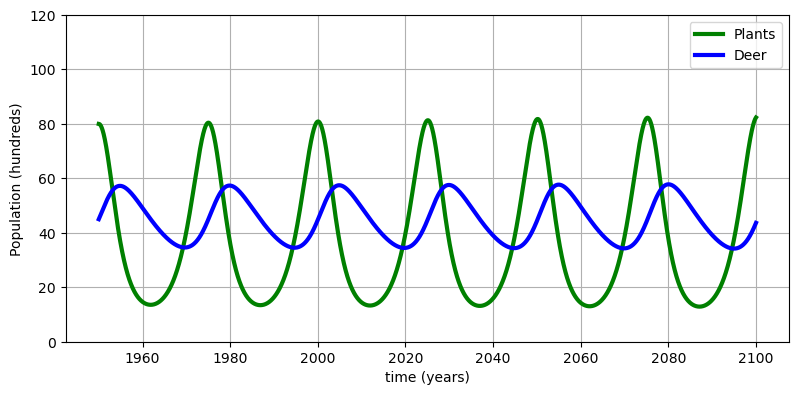

In [15]:

# Create a new figure for the plot with a specified size (width=8 inches, height=4 inches)
fig = plt.figure(figsize=(8, 4))

# Plot the plant population (P) against time using a green solid line ('g-')
# 'label' adds a name for the legend, and 'linewidth=3' makes the line thicker for visibility
plt.plot(time, P, 'g-', label='Plants', linewidth=3)

# Plot the deer population (D) against time using a blue solid line ('b-')
# Same styling as above but with a different color and label
plt.plot(time, D, 'b-', label='Deer', linewidth=3)

# Add a grid to the background of the plot for easier reading of values
plt.grid()

# Label the x-axis as 'time (years)'
plt.xlabel('time (years)')

# Label the y-axis as 'Population (hundreds)'
plt.ylabel('Population (hundreds)')

# Add a legend to identify the two lines (Plants and Deer)
# 'loc="best"' automatically chooses the best position for the legend
plt.legend(loc='best')

# Adjust the layout so labels and titles fit neatly without overlapping
plt.tight_layout()

# Set the y-axis limits from 0 to 120 to keep the plot focused on relevant values
plt.ylim([0, 120])


# Display the plot on the screen
plt.show()


## Reflective Exercise 5.2: Deer vs Plant

Look at the plot below showing:
* the deer population as a function of plant population

Answer the following questions using the plot:

* Does this system look like a **stable ecosystem**?  
  Explain your answer using the shape of the plot.

* If the deer population suddenly dropped to **half** its size, what do you think would happen to the system over time?


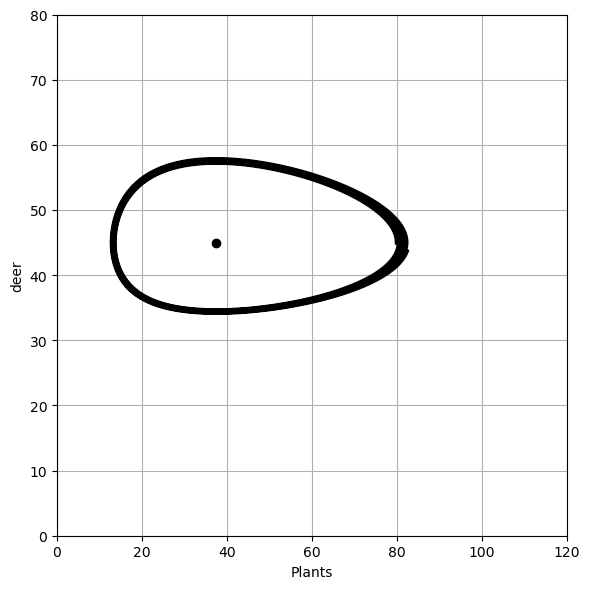

In [16]:

# Create a new figure for the plot with a square shape (6 inches by 6 inches)
fig = plt.figure(figsize=(6, 6))

# Plot the phase-plane relationship between Plants (P) and Deer (D)
# 'k-' means a black solid line, and linewidth=3 makes the line thick for visibility
plt.plot(P, D, 'k-', linewidth=3)

# Plot a single black dot ('ko') at the average (mean) values of Plants and Deer
# This represents the equilibrium point or average population over time
plt.plot(P.mean(), D.mean(), 'ko')

# Add a grid to the background for easier reading of values
plt.grid()

# Label the x-axis as 'Plants'
plt.xlabel('Plants')

# Label the y-axis as 'deer'
plt.ylabel('deer')

# Set the x-axis limits from 0 to 120 (to match plant population range)
plt.xlim(0, 120)

# Set the y-axis limits from 0 to 80 (to match deer population range)
plt.ylim(0, 80)

# Adjust layout so labels and plot fit neatly without overlapping
plt.tight_layout()

# Display the plot on the screen
plt.show()


## Wolves
Lets add wolves to the 

In [17]:

# INITIAL CONDITIONS

P = 80 * np.ones(N)  # Plant population array; start with 80 at every time index.
                  

D = 45 * np.ones(N)  # Deer population array; start with 45 at every time index.
                    

W = 5 * np.ones(N)   # Wolf population array; initialised to 5.
                     # However, wolves are set to zero before 2020 in the loop below.
                     # You might initialise to zeros instead and then turn them on at 2020.

# --- Parameter vectors encoding linear (per-capita) effects ---
SMALLplant = np.array([0.9, -0.02, 0.03])
# For plants: per-capita rate = 0.9 + (-0.02)*Deer + 0.03*Wolves
#  + 0.9   : intrinsic plant growth (per year)
#  - 0.02*D: plants eaten by deer (grazing pressure)
#  + 0.03*W: wolves indirectly benefit plants (e.g., by reducing deer), modeled here as positive

deer_constant = np.array([0.005 - 60*0.002, 0.002, -0.001])
# For deer: per-capita rate = (0.005 - 60*0.002) + 0.002*Plants + (-0.001)*Wolves
#  + 0.005            : small intrinsic growth term
#  - 60*0.002         : baseline loss term (constant offset); consider documenting why "60"
#  + 0.002*P          : deer reproduction rises with more plants (food)
#  - 0.001*W          : wolves reduce deer population

wolves_constant = np.array([-0.05, 0.001, 0.0])
# For wolves: per-capita rate = -0.05 + 0.001*Deer + 0.0*(unused)
#  - 0.05      : natural mortality / baseline decline
#  + 0.001*D   : wolves increase when there are more deer (food availability)

for i in range(1, N):
    # Update each time step (Euler method).
    # NOTE: i runs from 1 to N-1; we always refer to previous index (i-1) for "current" state.

    # --- Wolves before and after 2020 ---
    if time[i-1] < 2020:
        W[i-1] = 0
        # Before 2020, set wolves to zero (no wolves present).
        # Consider also setting W[i] = 0 here for consistency.
    else:
        # Wolves update once present:
        # W_next = W_current + dt * W_current * ( -0.05 + 0.001*D_current )
        W[i] = W[i-1] + timestep * W[i-1] * (wolves_constant[0] + wolves_constant[1] * (D[i-1]))

    # --- Plants update ---
    # P_next = P_current + dt * P_current * ( 0.9  - 0.02*D_current + 0.03*W_current )
    P[i] = P[i-1] + timestep * P[i-1] * (SMALLplant[0] + SMALLplant[1] * D[i-1] + SMALLplant[2] * W[i-1])

    # --- Deer update ---
    # D_next = D_current + dt * D_current * ( (0.005 - 60*0.002) + 0.002*P_current  - 0.001*W_current )
    D[i] = D[i-1] + timestep * D[i-1] * (deer_constant[0] + deer_constant[1] * (P[i-1]) + deer_constant[2] * W[i-1])


## Reflective Exercise 5.3: Wolves
Look at the graph below which shows the wolf population as a function of time

Answer the following questions using the plot:
* What happens to the wolf population before 2020?
* What happens to the wolf population after 2020? 
* Does their population remain constant or change over time? Explain what you see.


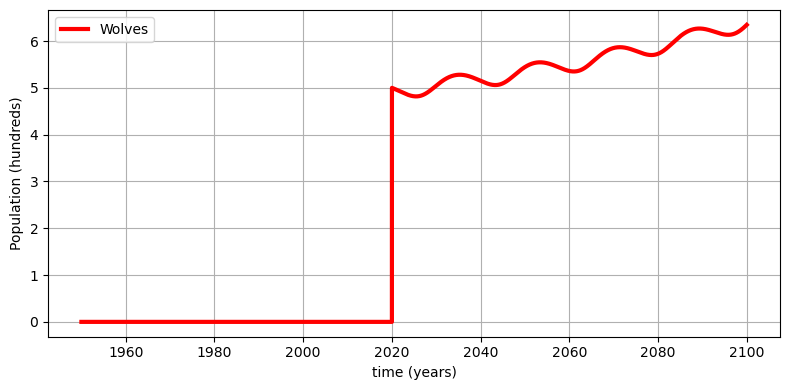

In [18]:

# Create a new figure for the plot with a specified size (width=8 inches, height=4 inches)
fig = plt.figure(figsize=(8, 4))

# Plot the wolf population (W) against time using a red solid line ('r-')
# 'label' adds a name for the legend, and 'linewidth=3' makes the line thicker for visibility
plt.plot(time, W, 'r-', label='Wolves', linewidth=3)

# Add a grid to the background of the plot for easier reading of values
plt.grid()

# Label the x-axis as 'time (years)'
plt.xlabel('time (years)')

# Label the y-axis as 'Population (hundreds)'
plt.ylabel('Population (hundreds)')

# Add a legend to identify the line (Wolves)
# 'loc="best"' automatically chooses the best position for the legend
plt.legend(loc='best')

# Adjust the layout so labels and titles fit neatly without overlapping
plt.tight_layout()

# Display the plot on the screen
plt.show()


## How does the introduction of Wolves impact Deer?

### Reflective Exercise 5.4
The plot below shows the deer and wolve population over time.
Answer the following questions using the plot:
* After wolves are introduced, what happens to the deer population?
* Does this surprise you?

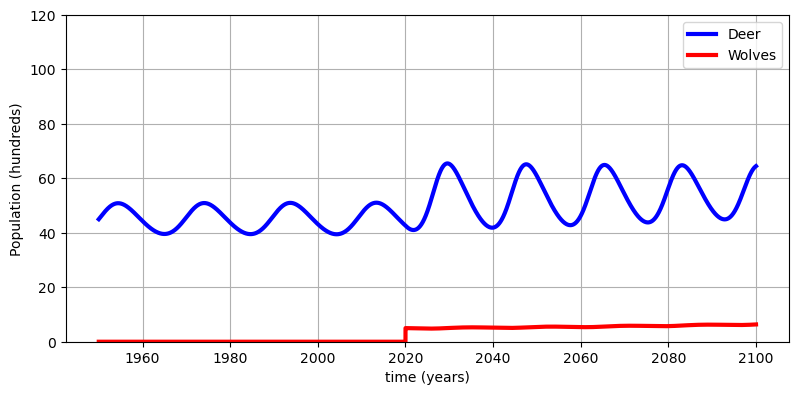

In [19]:

## PLOTTING

# Create a new figure for the plot with a specified size (width=8 inches, height=4 inches)
fig = plt.figure(figsize=(8, 4))

# Plot the deer population (D) against time using a blue solid line ('b-')
# 'linewidth=3' makes the line thicker for visibility, and 'label' adds a name for the legend
plt.plot(time, D, 'b-', linewidth=3, label='Deer')

# Plot the wolf population (W) against time using a red solid line ('r-')
# Same styling as above but with a different color and label
plt.plot(time, W, 'r-', linewidth=3, label='Wolves')

# Add a grid to the background of the plot for easier reading of values
plt.grid()

# Label the x-axis as 'time (years)'
plt.xlabel('time (years)')

# Label the y-axis as 'Population (hundreds)'
plt.ylabel('Population (hundreds)')

# Add a legend to identify the two lines (Deer and Wolves)
# 'loc="best"' automatically chooses the best position for the legend
plt.legend(loc='best')

# Adjust the layout so labels and titles fit neatly without overlapping
plt.tight_layout()

# Set the y-axis limits from 0 to 120 to keep the plot focused on relevant values
plt.ylim([0, 120])

# Display the plot on the screen
plt.show()


## Why do the plants benefit?

### Reflective Exercise 5.5: Wolves and Deer and Plants

Answer the following questions using the plot:
* After wolves are introduced, what happens to the plant population?
* Does this surprise you?


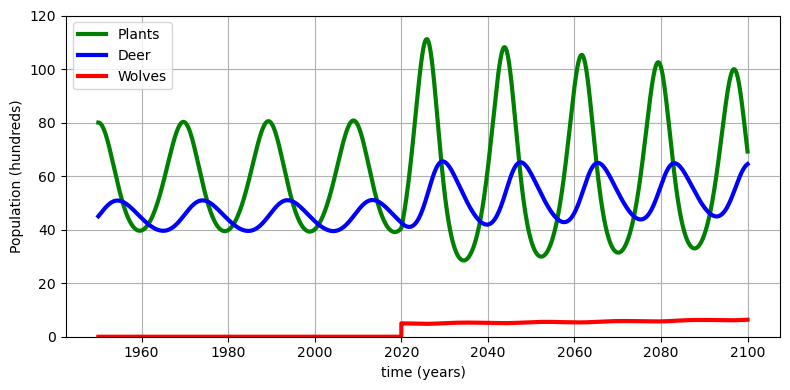

In [20]:

# Create a new figure for the plot with a specified size (width=8 inches, height=4 inches)
fig = plt.figure(figsize=(8, 4))

# Plot the plant population (P) against time using a green solid line ('g-')
# 'label' adds a name for the legend, and 'linewidth=3' makes the line thicker for visibility
plt.plot(time, P, 'g-', label='Plants', linewidth=3)

# Plot the deer population (D) against time using a blue solid line ('b-')
# Same styling as above but with a different color and label
plt.plot(time, D, 'b-', label='Deer', linewidth=3)

# Plot the wolf population (W) against time using a red solid line ('r-')
# This shows all three species together for comparison
plt.plot(time, W, 'r-', label='Wolves', linewidth=3)

# Add a grid to the background of the plot for easier reading of values
plt.grid()

# Set the y-axis limits from 0 to 120 to keep the plot focused on relevant values
plt.ylim([0, 120])

# Label the x-axis as 'time (years)'
plt.xlabel('time (years)')

# Label the y-axis as 'Population (hundreds)'
plt.ylabel('Population (hundreds)')

# Add a legend to identify the three lines (Plants, Deer, Wolves)
# 'loc="best"' automatically chooses the best position for the legend
plt.legend(loc='best')

# Adjust the layout so labels and titles fit neatly without overlapping
plt.tight_layout()

# Display the plot on the screen
plt.show()


## What does the new ecosystem look like?

### The Maths model Deer, Plants and Wolves
These recurrent equations for the plants, deer and wolves are:
\begin{equation}
\begin{array}{cl}
P=P+0.9P-0.002P\times D+0.003PW,\\
D=D-0.0075D+0.0001P \times D-0.001DW\\
W=W-0.05W+0.0001P \times W
\end{array}
\end{equation}
this set of equations models the interaction between plants (P), deer (D) and wolves (W). 



### Reflective Exercise 5.6: Deer vs Plant
Look at the plot below showing:
* the deer population as a function of plant population
Answer the following questions using the plot:
* What are the two circles?
* Do they look like a stable eco-systems?



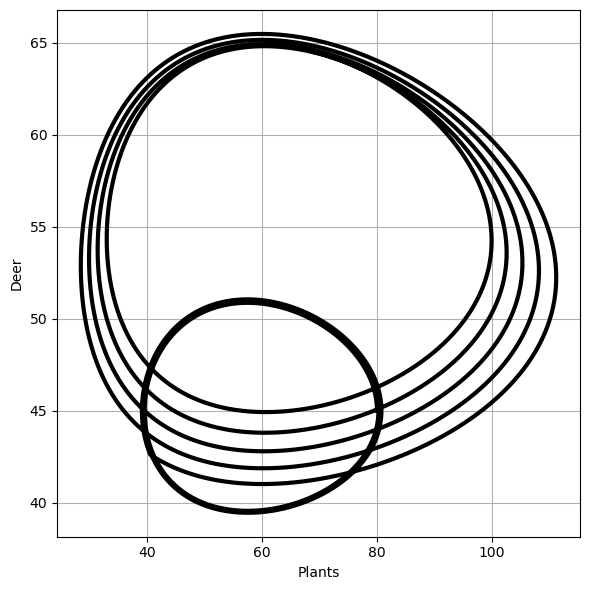

In [21]:

# Create a new figure for the plot with a square shape (6 inches by 6 inches)
fig = plt.figure(figsize=(6, 6))

# Plot the relationship between Plants (P) and Deer (D) as a black solid line ('k-')
# This is a phase-plane plot showing how the two populations interact over time
# 'linewidth=3' makes the line thicker for better visibility
plt.plot(P, D, 'k-', linewidth=3)

# Add a grid to the background for easier reading of values and to make the plot clearer
plt.grid()

# Label the x-axis as 'Plants' to indicate plant population values
plt.xlabel('Plants')

# Label the y-axis as 'Deer' to indicate deer population values
plt.ylabel('Deer')

# Adjust layout so labels and plot fit neatly without overlapping
plt.tight_layout()

# Display the plot on the screen
plt.show()


### Interactive Exercise 5.7: Enough Wolves
The interactive plot shows the plant, deer and wolf populations. The left plot shows shows the population as a function of time. The right plot shows the deer population as a function of the plant population.

Use the sliders to change the number of wolves introduced from 1 to 10.
 
Reflect on how each change impacts:
* The plant and deer populations.


In [22]:

def introduce_wolves(Wolf=5):
    timestep=0.01
    time = np.arange(1950, 2100+timestep/2, timestep )              # time
    N=len(time)
    P=80*np.ones(N) # 
    D=45*np.ones(N) # 
    W=Wolf*np.ones(N) # 

    SMALLplant = np.array( [0.9,-0.02,0.03])
    deer_constant= np.array([0.005-60*0.002,0.002,-0.001])
    wolves_constant= np.array([-0.05,0.001,0.0])

    for i in range (1,N):
        if time[i-1]<2020:
            W[i-1]=0
        else:
            W[i]=W[i-1]+timestep*W[i-1]*(wolves_constant[0]+wolves_constant[1]*(D[i-1]))
        
        P[i]=P[i-1]+timestep*P[i-1]*(SMALLplant[0]+SMALLplant[1]*D[i-1]+SMALLplant[2]*W[i-1])
        D[i]=D[i-1]+timestep*D[i-1]*(deer_constant[0]+deer_constant[1]*(P[i-1])+deer_constant[2]*W[i-1])


    fig, (pop_ax, orbit_ax) = plt.subplots(1, 2, figsize=(12, 6))

    # Population dynamics over time
    pop_ax.plot(time, P, 'g-', label='Plants',linewidth=3)
    pop_ax.plot(time, D, 'b-', label='Deer',linewidth=3)
    pop_ax.plot(time, W, 'r-', label='Wolves',linewidth=3)
    pop_ax.set_xlabel('Time (years)')
    pop_ax.set_ylabel('Population (hundreds)')
    pop_ax.set_ylim(0, 150)
    pop_ax.legend()

    # Phase portrait (orbit)
    orbit_ax.plot(P, D, 'k-', linewidth=3)
    orbit_ax.set_xlabel('Plants ')
    orbit_ax.set_ylabel('Deer')
    orbit_ax.set_xlim(0, 150)
    orbit_ax.set_ylim(0, 150)

    plt.tight_layout()
    plt.show()


In [23]:
interact(introduce_wolves,
         Wolf=FloatSlider(min=0.0, max=10.0, step=0.5, value=5.0)
         )

interactive(children=(FloatSlider(value=5.0, description='Wolf', max=10.0, step=0.5), Output()), _dom_classes=…

<function __main__.introduce_wolves(Wolf=5)>

## Summary and Outro
- The Deer and Plants were in a stable eco-system

- The re-introduction of wolves benefited both the plants and deer

- The new eco-system was also stable eco-system but with a larger orbit


